# ArvyaX ML Assignment
End-to-end pipeline for emotion prediction, intensity prediction, decision engine, and uncertainty modeling.

In [73]:
# Install required packages (run this once)
!pip install pandas numpy scikit-learn xgboost matplotlib seaborn

In [74]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier, XGBRegressor
import matplotlib.pyplot as plt



## Load Training and Test Data

In [75]:
train = pd.read_csv('data/Sample_arvyax_reflective_dataset.xlsx - Dataset_120.csv')
test = pd.read_csv('data/arvyax_test_inputs_120.xlsx - Sheet1.csv')

print(train.shape)
train.head()

(1200, 13)


,id,journal_text,ambience_type,duration_min,sleep_hours,energy_level,stress_level,time_of_day,previous_day_mood,face_emotion_hint,reflection_quality,emotional_state,intensity
0,1,The ocean ambience helped me stop drifting and...,ocean,12,6.5,4,2,afternoon,mixed,calm_face,clear,focused,3
1,2,"I tried to relax during the forest ambience, y...",forest,35,6.0,2,4,evening,calm,tired_face,vague,restless,3
2,3,The forest session slowed my thoughts and I fe...,forest,3,NaN,2,1,night,overwhelmed,happy_face,clear,calm,3
3,4,"the mountain ambience was pleasant, though i c...",mountain,25,7.0,4,4,night,focused,calm_face,vague,neutral,1
4,5,"The rain session gave me a pause, but the pres...",rain,25,5.0,3,5,afternoon,NaN,tense_face,clear,overwhelmed,5


## Define Feature Columns

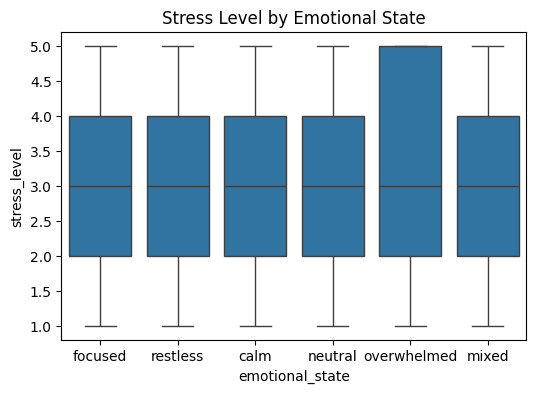

In [76]:
import seaborn as sns

plt.figure(figsize=(6,4))

sns.boxplot(
    x='emotional_state',
    y='stress_level',
    data=train
)

plt.title("Stress Level by Emotional State")
plt.show()

In [77]:
TEXT_COL = 'journal_text'

CAT_COLS = [
    'ambience_type',
    'time_of_day',
    'previous_day_mood',
    'face_emotion_hint',
    'reflection_quality'
]

NUM_COLS = [
    'duration_min',
    'sleep_hours',
    'energy_level',
    'stress_level'
]

## Encode Emotion Labels

In [78]:
le = LabelEncoder()
train['state_encoded'] = le.fit_transform(train['emotional_state'])

## Preprocessing Pipeline

In [79]:
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=3000, ngram_range=(1,2), stop_words='english'), TEXT_COL),
        ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_COLS),
        ('num', SimpleImputer(strategy='median'), NUM_COLS)
    ]
)

## Train Emotional State Model

In [80]:
state_model = Pipeline([
    ('prep', preprocessor),
    ('model', XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, eval_metric='mlogloss'))
])

X_train = train[[TEXT_COL] + CAT_COLS + NUM_COLS]
y_state = train['state_encoded']

state_model.fit(X_train, y_state)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

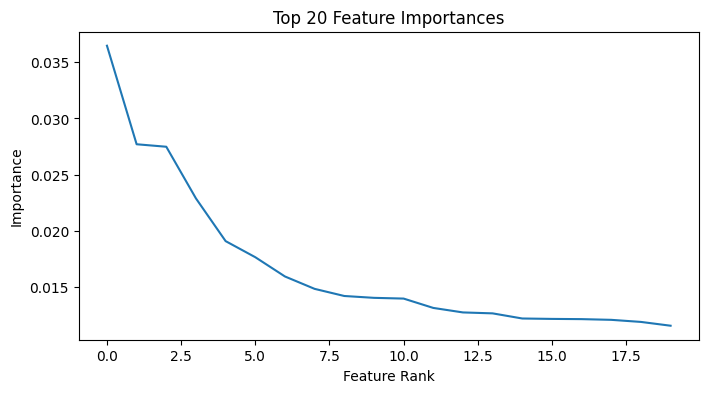

In [81]:
# Feature Importance

model = state_model.named_steps['model']

importances = model.feature_importances_

import numpy as np

sorted_importances = np.sort(importances)[::-1][:20]

plt.figure(figsize=(8,4))
plt.plot(sorted_importances)
plt.title("Top 20 Feature Importances")
plt.xlabel("Feature Rank")
plt.ylabel("Importance")
plt.show()

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train2, X_val, y_train2, y_val = train_test_split(
    X_train, y_state, test_size=0.2, random_state=42
)

# Full model (text + metadata)
state_model.fit(X_train2, y_train2)
pred_full = state_model.predict(X_val)

print("Text + Metadata Accuracy:", accuracy_score(y_val, pred_full))

Text + Metadata Accuracy: 0.6791666666666667


## Train Intensity Model

In [83]:
intensity_model = Pipeline([
    ('prep', preprocessor),
    ('model', XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05))
])

y_intensity = train['intensity']

intensity_model.fit(X_train, y_intensity)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## Decision Engine

In [84]:
def decision_engine(state, intensity, stress, energy, time_of_day):

    reason = ""

    if stress >= 4:
        action = "box_breathing"
        when = "now"
        reason = "high stress detected"

    elif state == "restless":
        action = "movement"
        when = "within_15_min"
        reason = "restlessness benefits from physical activity"

    elif state == "calm" and energy >= 4:
        action = "deep_work"
        when = "within_15_min"
        reason = "high energy and calm state support focus"

    elif energy <= 2:
        action = "rest"
        when = "later_today"
        reason = "low energy detected"

    elif time_of_day == "night":
        action = "journaling"
        when = "tonight"
        reason = "night reflection recommended"

    else:
        action = "light_planning"
        when = "later_today"
        reason = "moderate state detected"

    return action, when, reason

In [85]:
def supportive_message(state, action):

    if action == "box_breathing":
        return "You seem stressed right now. A short breathing exercise could help reset."

    if action == "deep_work":
        return "Your energy looks good. This is a great time to focus on meaningful work."

    if action == "rest":
        return "Your energy seems low. Taking a short rest may help you recover."

    return "Take a moment to slow down and reflect."

## Run Predictions

In [87]:
X_test = test[[TEXT_COL] + CAT_COLS + NUM_COLS].copy()

# ensure columns match
for col in X_train.columns:
    if col not in X_test.columns:
        X_test[col] = np.nan

X_test = X_test[X_train.columns]

state_probs = state_model.predict_proba(X_test)

state_pred = np.argmax(state_probs, axis=1)

predicted_state = le.inverse_transform(state_pred)

confidence = np.max(state_probs, axis=1)

ValueError: Feature shape mismatch, expected: 1473, got 1622

In [88]:
from sklearn.ensemble import RandomForestClassifier

meta_only = train[CAT_COLS + NUM_COLS]

rf = RandomForestClassifier()

rf.fit(meta_only, y_state)

pred_meta = rf.predict(meta_only)

ValueError: could not convert string to float: 'ocean'

## Uncertainty Modeling

In [ ]:
def uncertainty_flag(conf, text):

    if conf < 0.55:
        return 1

    if len(str(text).split()) < 3:
        return 1

    return 0

## Decision + Output

In [ ]:
actions = []
times = []
reasons = []
uncertainties = []
messages = []


for i in range(len(test)):

    row = test.iloc[i]

    action, when, reason = decision_engine(
        predicted_state[i],
        predicted_intensity[i],
        row["stress_level"],
        row["energy_level"],
        row["time_of_day"]
    )
    message = supportive_message(predicted_state[i], action)

    actions.append(action)
    times.append(when)
    reasons.append(reason)
    messages.append(message)
    uncertainties.append(1 if confidence[i] < 0.55 else 0)

## Save Predictions

In [ ]:
output = pd.DataFrame({

    "id": test["id"],
    "predicted_state": predicted_state,
    "predicted_intensity": predicted_intensity,
    "confidence": confidence,
    "uncertain_flag": uncertainties,
    "what_to_do": actions,
    "when_to_do": times,
    "decision_reason": reasons

})

output.to_csv('predictions.csv',index=False)
output.head()

In [ ]:
plt.hist(confidence, bins=20)

plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# Robustness Tests

test_cases = [
    "ok",
    "fine",
    "great day today",
    "very stressed and tired",
    "hmm"
]

for text in test_cases:
    
    sample = test.iloc[0:1].copy()
    sample["journal_text"] = text
    
    probs = state_model.predict_proba(
        sample[[TEXT_COL] + CAT_COLS + NUM_COLS]
    )
    
    print(text, "confidence =", np.max(probs))

In [ ]:
sample = test.iloc[0]

print("User reflection:")
print(sample["journal_text"])

print("\nPredicted emotion:", predicted_state[0])
print("Predicted intensity:", predicted_intensity[0])
print("Confidence:", confidence[0])
print("Recommended action:", actions[0])
print("Recommended time:", times[0])

In [ ]:
import joblib

joblib.dump(state_model, "state_model.pkl")
joblib.dump(intensity_model, "intensity_model.pkl")
joblib.dump(le, "label_encoder.pkl")